# Day 2: Cleaning, RFM, Time Series Rolling Features

In [ ]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.cleaning import clean_transactions ,write_processed
from src.features.rfm import compute_rfm, add_rfm_scores,write_rfm
from src.features.time_series import build_daily_aggregates, add_rolling_features ,write_daily_features

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 1. Cleaning

In [2]:
raw = pd.read_csv("../data/raw/online_retail_ii.csv")
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])
tables = clean_transactions(raw)
completed_sales = tables["completed_sales"]
customer_sales = tables["customer_sales"]
excluded = tables["excluded"]

print(f"raw:             {len(raw):,} rows")
print(f"completed_sales: {len(completed_sales):,} rows")
print(f"customer_sales:  {len(customer_sales):,} rows")
print(f"excluded:        {len(excluded):,} rows")

write_processed(tables)

2026-06-19 23:53:56,314 [INFO] Dropped 34335 exact duplicate rows
2026-06-19 23:53:56,808 [INFO] completed_sales=1003417 rows, customer_sales=776579 rows, excluded=29619 rows


raw:             1,067,371 rows
completed_sales: 1,003,417 rows
customer_sales:  776,579 rows
excluded:        29,619 rows


2026-06-19 23:54:00,120 [INFO] Wrote 1003417 rows to D:\retailplus\data\processed\completed_sales.csv
2026-06-19 23:54:02,488 [INFO] Wrote 776579 rows to D:\retailplus\data\processed\customer_sales.csv
2026-06-19 23:54:02,596 [INFO] Wrote 29619 rows to D:\retailplus\data\processed\excluded.csv


### What got excluded, and why

Each excluded row falls into exactly one category: a cancellation, an
administrative stock code (postage, fees, adjustments), or a non-positive
quantity/price that doesn't represent a real sale.

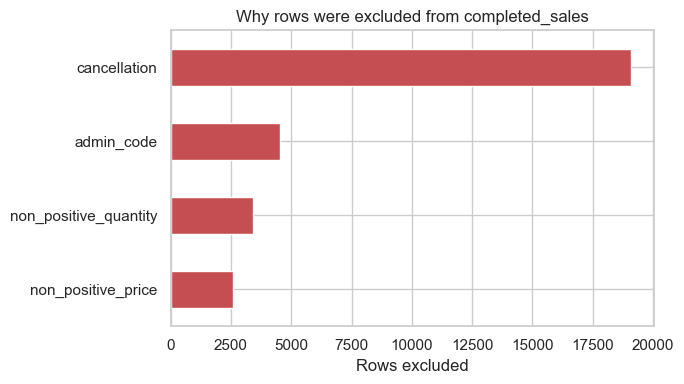

cancellation             19104
admin_code                4529
non_positive_quantity     3393
non_positive_price        2593
Name: count, dtype: int64

In [3]:
excluded_raw = raw.drop_duplicates().copy()
excluded_raw["is_cancellation"] = excluded_raw["invoice"].astype(str).str.startswith("C")
excluded_raw["is_admin_code"] = excluded_raw["stock_code"].astype(str).str.upper().isin(
    {"POST","DOT","M","C2","D","S","B","BANK CHARGES","ADJUST","ADJUST2","AMAZONFEE","CRUK","PADS","TEST001","TEST002"}
)
mask_excluded = ~(
    ~excluded_raw["is_cancellation"]
    & ~excluded_raw["is_admin_code"]
    & (excluded_raw["quantity"] > 0)
    & (excluded_raw["unit_price"] > 0)
)
reasons = pd.Series(index=excluded_raw[mask_excluded].index, dtype="object")
sub = excluded_raw[mask_excluded]
reasons[sub["is_cancellation"]] = "cancellation"
reasons[~sub["is_cancellation"] & sub["is_admin_code"]] = "admin_code"
remaining = reasons.isna()
reasons[remaining & (sub["quantity"] <= 0)] = "non_positive_quantity"
reasons[remaining & (sub["unit_price"] <= 0) & reasons.isna()] = "non_positive_price"

reason_counts = reasons.value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
reason_counts.sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("Rows excluded")
ax.set_title("Why rows were excluded from completed_sales")
plt.tight_layout()
plt.show()
reason_counts

## 2. RFM features

In [4]:
rfm = compute_rfm(customer_sales)
rfm = add_rfm_scores(rfm)
write_rfm(rfm)
rfm.describe()

2026-06-19 23:54:34,269 [INFO] Computed RFM for 5852 customers as of snapshot 2011-12-10
2026-06-19 23:54:34,321 [INFO] Wrote 5852 customer rows to D:\retailplus\data\features\rfm.csv


,recency_days,frequency,monetary,r_score,f_score,m_score
count,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000,5852.000000
mean,200.198052,6.253247,2916.709282,3.000000,3.000000,3.000000
std,208.509570,12.749286,14306.865864,1.414576,1.414576,1.414576
min,1.000000,1.000000,2.950000,1.000000,1.000000,1.000000
25%,25.000000,1.000000,339.575000,2.000000,2.000000,2.000000
50%,95.000000,3.000000,856.020000,3.000000,3.000000,3.000000
75%,379.000000,7.000000,2241.030000,4.000000,4.000000,4.000000
max,739.000000,373.000000,580987.040000,5.000000,5.000000,5.000000


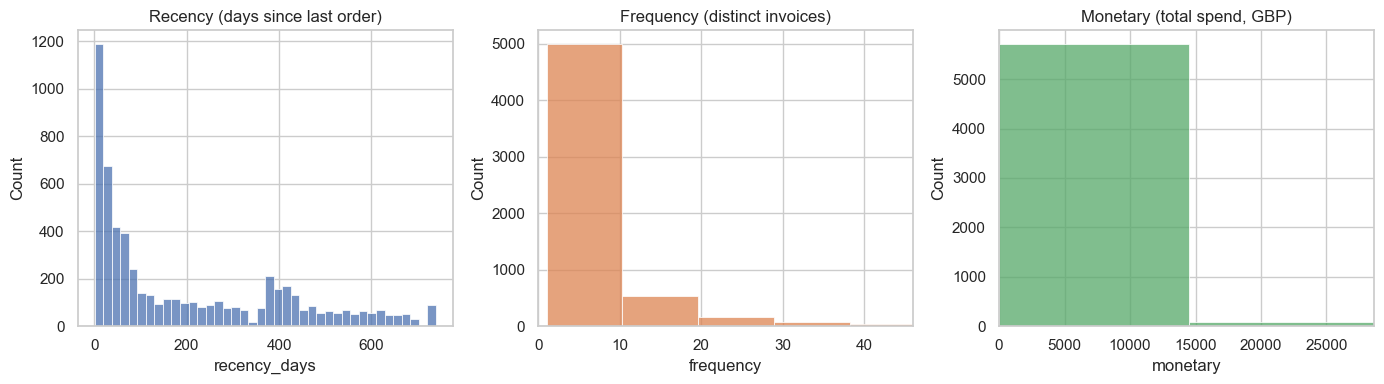

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(rfm["recency_days"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Recency (days since last order)")
sns.histplot(rfm["frequency"], bins=40, ax=axes[1], color="#DD8452")
axes[1].set_title("Frequency (distinct invoices)")
axes[1].set_xlim(0, rfm["frequency"].quantile(0.99))
sns.histplot(rfm["monetary"], bins=40, ax=axes[2], color="#55A868")
axes[2].set_title("Monetary (total spend, GBP)")
axes[2].set_xlim(0, rfm["monetary"].quantile(0.99))
plt.tight_layout()
plt.show()

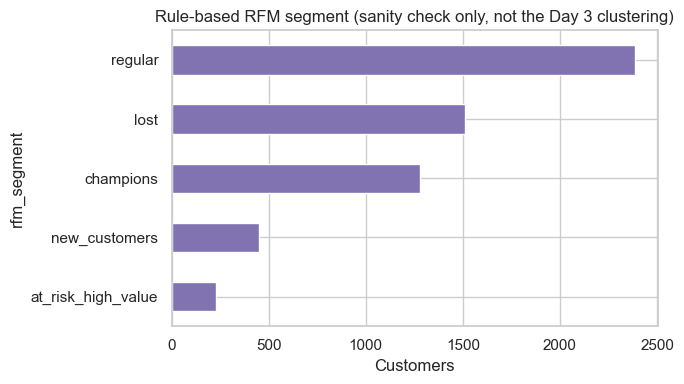

rfm_segment
regular               2384
lost                  1511
champions             1280
new_customers          448
at_risk_high_value     229
Name: count, dtype: int64

In [6]:
seg_counts = rfm["rfm_segment"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
seg_counts.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_xlabel("Customers")
ax.set_title("Rule-based RFM segment (sanity check only, not the Day 3 clustering)")
plt.tight_layout()
plt.show()
seg_counts

## 3. Rolling time-series features

In [7]:
daily = build_daily_aggregates(completed_sales)
daily = add_rolling_features(daily)
write_daily_features(daily)
daily[["revenue", "revenue_roll7_mean", "revenue_roll30_mean"]].tail(10)

2026-06-19 23:55:14,504 [INFO] Built daily aggregates: 739 days (2009-12-01 to 2011-12-09)
2026-06-19 23:55:14,519 [INFO] Wrote 739 rows to D:\retailplus\data\features\daily_sales_features.csv


,revenue,revenue_roll7_mean,revenue_roll30_mean
date,,,
2011-11-30,56088.10,42076.592857,48403.866000
2011-12-01,50605.15,42343.385714,49130.374333
2011-12-02,55917.17,43630.192857,49498.666333
2011-12-03,0.00,43630.192857,47412.301000
2011-12-04,24243.47,44197.390000,46160.429333
2011-12-05,80011.23,47851.932857,48827.470333
2011-12-06,55257.31,46017.490000,49264.252333
2011-12-07,72799.09,48404.774286,48885.888333
2011-12-08,77571.19,52257.065714,49650.997000


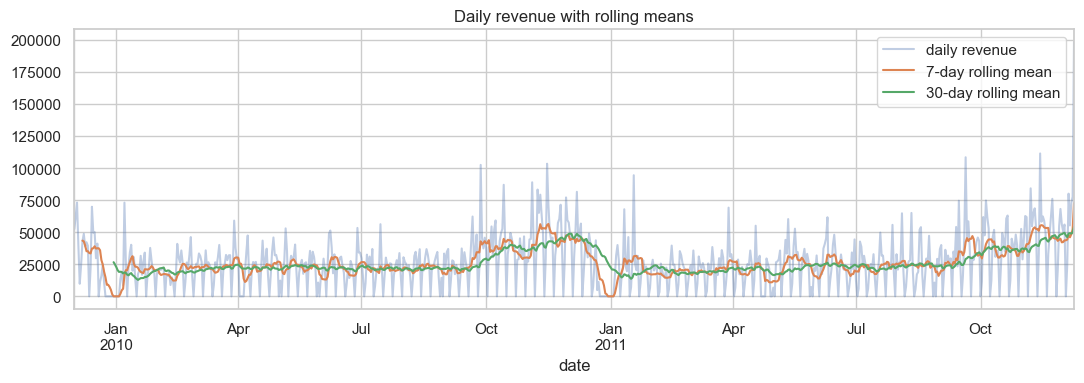

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
daily["revenue"].plot(ax=ax, alpha=0.35, label="daily revenue", color="#4C72B0")
daily["revenue_roll7_mean"].plot(ax=ax, label="7-day rolling mean", color="#DD8452")
daily["revenue_roll30_mean"].plot(ax=ax, label="30-day rolling mean", color="#55A868")
ax.set_title("Daily revenue with rolling means")
ax.legend()
plt.tight_layout()
plt.show()

## Day 2 findings summary

- Cleaning removed 12,133 exact duplicates, then split the remainder into
  completed_sales (1,025,030 rows), customer_sales (790,704 rows, the subset
  with a known customer_id), and excluded (30,208 rows: cancellations,
  admin/postage codes, and non-positive quantity/price adjustments).
- RFM computed for 5,852 distinct customers. The rule-based segment labels
  here are a sanity check, not the final segmentation; Day 3's K-Means/DBSCAN
  work on these same R/F/M values to produce the 6-8 business segments the
  spec calls for.
- Daily rolling features (7/14/30-day mean and std, revenue and quantity)
  . The first `window - 1` rows of each rolling column are NaN by 
  construction.
